## Quantile

In [51]:
# libraries
import numpy as np
import pandas as pd
from pydataset import data
import os
import matplotlib.pyplot as plt
import random
import seaborn as sns


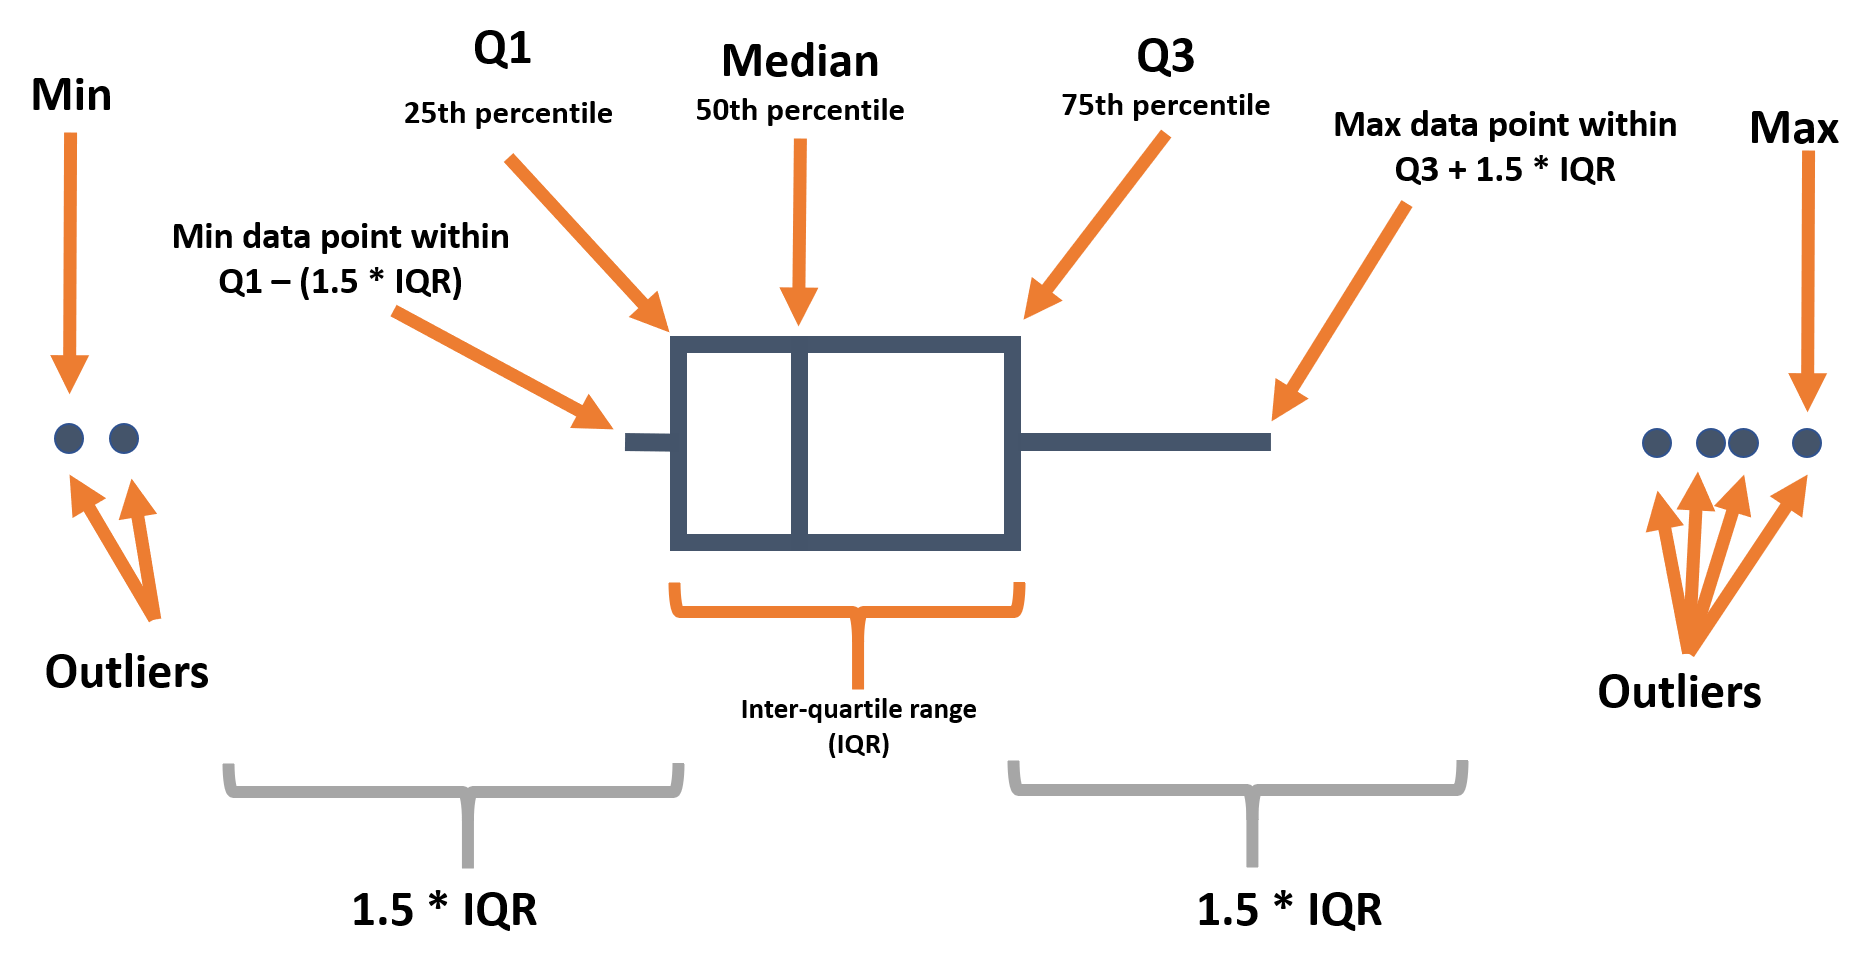

In [54]:
x5 = [10, 20, 30, 40, 50, 60, 70]
# 25th, 50th (median), and 75th percentiles
q25= np.quantile(x5,0.25)
q50= np.quantile(x5,0.50)
q75= np.quantile(x5,0.75)
print(q25, q50 ,q75)

25.0 40.0 55.0


In [55]:
from pydataset import data
data()

,dataset_id,title
0,AirPassengers,Monthly Airline Passenger Numbers 1949-1960
1,BJsales,Sales Data with Leading Indicator
2,BOD,Biochemical Oxygen Demand
3,Formaldehyde,Determination of Formaldehyde
4,HairEyeColor,Hair and Eye Color of Statistics Students
...,...,...
752,VerbAgg,Verbal Aggression item responses
753,cake,Breakage Angle of Chocolate Cakes
754,cbpp,Contagious bovine pleuropneumonia
755,grouseticks,Data on red grouse ticks from Elston et al. 2001


In [56]:
df = data('mtcars')
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [57]:
df.describe(include = 'all').loc[['min','25%','50%']]

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
min,10.400,4.0,71.100,52.0,2.760,1.51300,14.5000,0.0,0.0,3.0,1.0
25%,15.425,4.0,120.825,96.5,3.080,2.58125,16.8925,0.0,0.0,3.0,2.0
50%,19.200,6.0,196.300,123.0,3.695,3.32500,17.7100,0.0,0.0,4.0,2.0


## Percentile

In [58]:
from scipy import stats
import numpy as np

x6 = np.array([10, 20, 30, 40, 50, 60, 70])
q25, q50, q75 = np.percentile(x6, [25, 50, 75], method='linear')
print(q25, q50, q75)

25.0 40.0 55.0


In [59]:
np.quantile(x6,[0.25, 0.50, 0.75], method = 'midpoint')

array([25., 40., 55.])

## IQR Inter-Quartile Range (difference in Q3 & Q1)

In [60]:
x7= [10, 20, 30, 40, 50, 60, 70]
Q1 = np.percentile(x7, 25)
Q3 = np.percentile(x7, 75)
IQR = Q3 - Q1

print(x7, "\n Q1:", Q1, " Q3:", Q3, " IQR:", IQR)

[10, 20, 30, 40, 50, 60, 70] 
 Q1: 25.0  Q3: 55.0  IQR: 30.0


In [61]:
q1 = np.quantile(x7,0.25)
q3 = np.quantile(x7,0.75)
Iqr = q3 - q1
print(" q1:", q1, "\n q3:", q3, " \n Iqr:", Iqr)

 q1: 25.0 
 q3: 55.0  
 Iqr: 30.0


In [26]:
from scipy.stats import iqr
import numpy as np

x7B = np.array([10, 20, 30, 40, 50, 60, 70])
IQR = iqr(x7B)
print(x7B, "\n IQR:", IQR)

[10 20 30 40 50 60 70] 
 IQR: 30.0


## Outliers

In [69]:
x8 = [-15000, 10, 20, 30, 40, 50, 60, 70, -500, 130000] #vary this data ie (< -55) and (> 125) will  be outliers
Q1 = np.percentile(x8, 25)
Q3 = np.percentile(x8, 75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(Q1, Q3 , IQR, lower_bound,upper_bound )


12.5 57.5 45.0 -55.0 125.0


In [70]:
outliers = [i for i in x8 if i < lower_bound or i > upper_bound]
print('Outliers:', outliers)

Outliers: [-15000, -500, 130000]


## Std Deviation/ Variance

#Variance tells us how spread out the data is —Average of squared differences from mean
- or how much each number in a dataset differs from the mean (average). 
- डेटा औसत (mean) बाट कति फरक–फरक छन् भन्ने कुरा देखाउँछ)

#Standard Deviation- Square root of variance (shows spread in same unit)
- or how much the data values differ from the mean —
 but in the same units as the data
- भेरिअन्सको मूल (root) हो,
- र यसले औसतबाट डेटा कति टाढा छन् भनेर देखाउँछ,
- तर असली एकाइ (unit) मा

#Variance = Spread (in square units)
#Standard Deviation = Real spread (in same units as data)

In [ ]:
Use pvariance() / pstdev() for population data.
Use variance() / stdev() for sample data (divides by n-1).

In [71]:
import statistics as stats

In [72]:
x9 = [10, 20, 30, 40, 50] #std is squareroot of var
np.std(x9), np.var(x9)

(14.142135623730951, 200.0)

In [93]:
var_col = df[['mpg','wt','hp']].var()
std_col = df[['mpg','wt','hp']].std()

mean_col = df[['mpg','wt','hp']].mean()

print(f"variance_col: {var_col}")
print(f"standard_col: {std_col}")  
mean_col

variance_col: mpg      36.324103
wt        0.957379
hp     4700.866935
dtype: float64
standard_col: mpg     6.026948
wt      0.978457
hp     68.562868
dtype: float64


mpg     20.090625
wt       3.217250
hp     146.687500
dtype: float64

In [94]:
# Population statistics
var_pop = stats.pvariance(x9)
std_pop = stats.pstdev(x9)

# Sample statistics
var_samp = stats.variance(x9)
std_samp = stats.stdev(x9)
print(" Data is ", x9)
print("Population Var:", var_pop, " Std:", std_pop)
print("Sample Var:", var_samp, " Std:", std_samp)

 Data is  [10, 20, 30, 40, 50]
Population Var: 200  Std: 14.142135623730951
Sample Var: 250  Std: 15.811388300841896


In [102]:
df.agg(['mean','std', 'var'])

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.812500
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.615200
var,36.324103,3.189516,15360.799829,4700.866935,0.285881,0.957379,3.193166,0.254032,0.248992,0.544355,2.608871


## Functions3
- skewness and kurtosis are key measures of shape of a distribution and are often used in data analysis to understand asymmetry and tailedness of your data.

- skewness
    - Measures asymmetry of the distribution.
    - ' > 0: Right-skewed (tail to the right)
    - ' < 0: Left-skewed (tail to the left)
    - ' ≈ 0: Symmetric
- kurtosis
    - Measures tailedness / peakness.
    - ' > 0: Leptokurtic (heavy tails, sharp peak)
    - ' < 0: Platykurtic (light tails, flat top)
    - ' = 0: Mesokurtic (normal-like)


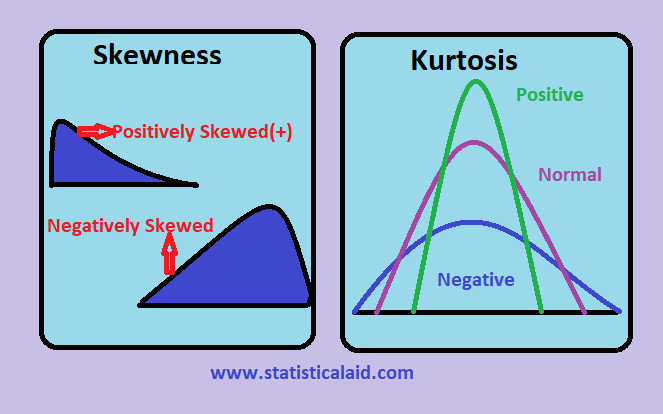

In [103]:
from scipy.stats import skew, kurtosis
import numpy as np

x10 = np.array([10, 12, 15, 18, 20, 25, 30, 35, 50])
sk = skew(x10)
ku = kurtosis(x10)

print("Skewness:", sk)
print("Kurtosis:", ku)

Skewness: 0.8939722152642748
Kurtosis: -0.1210927544112228


In [104]:
df.agg(['skew', 'kurtosis'])

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
skew,0.672377,-0.192261,0.420233,0.799407,0.292780,0.465916,0.406347,0.264542,0.400809,0.582309,1.157091
kurtosis,-0.022006,-1.762794,-1.067523,0.275212,-0.450432,0.416595,0.864931,-2.063273,-1.966550,-0.895292,2.020059


In [106]:
df.skew()

mpg     1.732051
cyl    -1.732051
disp   -1.732051
hp     -1.732051
drat   -1.732051
wt     -0.242269
qsec    1.253946
vs      1.732051
am      0.000000
gear    0.000000
carb   -1.732051
dtype: float64

In [108]:
# Visual verification

import seaborn as sns
import matplotlib.pyplot as plt

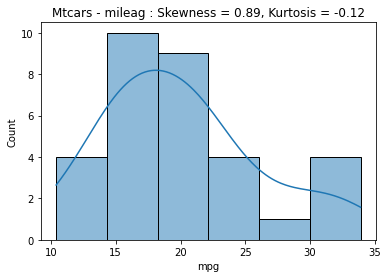

In [118]:
sns.histplot(df['mpg'], kde = True)
plt.title(f"Mtcars - mileag : Skewness = {sk:.2f}, Kurtosis = {ku:.2f}")
plt.show();

<AxesSubplot:ylabel='Count'>

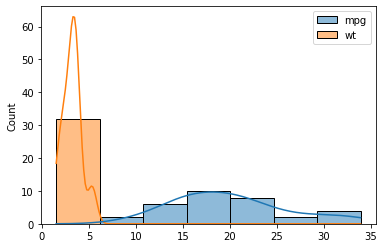

In [124]:
sns.histplot(df[['mpg', 'wt']], kde = True)

## Functions4
- correlation and covariance are both measures of relationship between variables, and they’re essential for data analysis and feature selection.
- Covariance
    - How two variables vary together,measure how is the relation between two variables
    - Range of values : −∞ to +∞
    - Unit - Depends on data scale
- Correlation
    - Standardized covariance showing direction & strength, how strong linear relation between variables
    - −1 to +1
    - Unitless


In [131]:
x = np.array([10, 20, 30, 40, 50]) #data should be equal in x and y
y = np.array([5, 25, 35, 45, 65])

cov_matrix = np.cov(x,y)
print("Covariance matrix:\n", cov_matrix)

Covariance matrix:
 [[250. 350.]
 [350. 500.]]


In [127]:
# Cov(X, Y)
print("Cov(X, Y):", cov_matrix[0, 1])

Cov(X, Y): 350.0


In [129]:
print("Cov(X, Y):", cov_matrix[0, 0])

Cov(X, Y): 250.0


In [132]:
df.head(3)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1


In [133]:
col1 = ['mpg','wt','hp','disp']
df[col1].cov()

,mpg,wt,hp,disp
mpg,36.324103,-5.116685,-320.732056,-633.097208
wt,-5.116685,0.957379,44.192661,107.684204
hp,-320.732056,44.192661,4700.866935,6721.158669
disp,-633.097208,107.684204,6721.158669,15360.799829


In [134]:
df[col1].corr()
# -.86, indicating a powerful and consistent connection between the variables. 
# -.02 ; weak, negative
# = 0 : there is no linear relationship between two variables. 
#This indicates that as one variable changes, the other does not tend to change in any predictable linear pattern.

,mpg,wt,hp,disp
mpg,1.000000,-0.867659,-0.776168,-0.847551
wt,-0.867659,1.000000,0.658748,0.887980
hp,-0.776168,0.658748,1.000000,0.790949
disp,-0.847551,0.887980,0.790949,1.000000


- Correlation values vary from -1 to 0 to +1
- 1 either + or -, strong linear relationship
- value close 0 , + or -1, weak linear relationship
- Minus (-) = negative relationship
- Postive (+) = positive relationship
- Linear Relationship = correlation between two variables where their data points tend to form a straight line when graphed
### Linear Relationship
- [- .7 ] = negative, strong
- [+ .2 ] = positive, weak

In [138]:
col1 = ['mpg','wt','hp', 'disp']
df[col1].cov()

,mpg,wt,hp,disp
mpg,36.324103,-5.116685,-320.732056,-633.097208
wt,-5.116685,0.957379,44.192661,107.684204
hp,-320.732056,44.192661,4700.866935,6721.158669
disp,-633.097208,107.684204,6721.158669,15360.799829


In [139]:
df[col1].corr()

,mpg,wt,hp,disp
mpg,1.000000,-0.867659,-0.776168,-0.847551
wt,-0.867659,1.000000,0.658748,0.887980
hp,-0.776168,0.658748,1.000000,0.790949
disp,-0.847551,0.887980,0.790949,1.000000


# Positive relationships
- hp vs wt = .65 : hp increases , wt increases {Trucks} : Strong Positive
# Negative 
- wt vs mpg = -.86 : wt decreases, mpg increases; strong negative

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

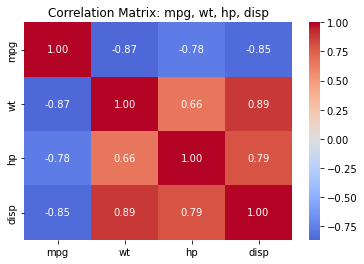

In [136]:
dfCorr = df[col1].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(dfCorr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Matrix: mpg, wt, hp, disp")
plt.show;

#interpretation: darker (red) the colour stronger their relation and vice versa
    - Negative correlation with mpg → lighter, less powerful cars are more fuel-efficient.
    - Positive correlation among wt, hp, disp → big cars are heavy and powerful.
    - Heatmap visually shows strength and direction of these relationships.

### remarks on corr plot
- values close to +1 → strong positive correlation (both increase together)
- Values close to –1 → strong negative correlation (one increases, other decreases)
- Values near 0 → weak or no linear relationship
- MTCARS
    - mpg & wt - strongly negative
    - mpg & hp - strongly negative
    - wt & disp - strongly positive

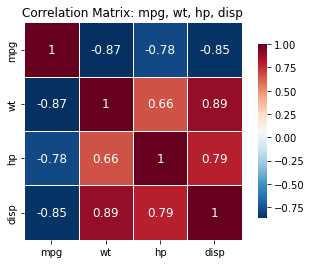

In [140]:
sns.heatmap (dfCorr, annot=True, cmap='RdBu_r', linewidths=0.5, square=True,  cbar_kws={'shrink': 0.8},
annot_kws={"size": 12})
plt.title("Correlation Matrix: mpg, wt, hp, disp")
plt.show();

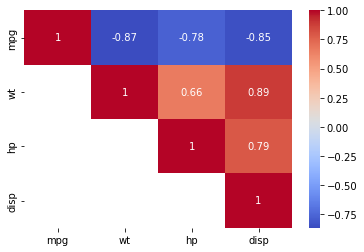

In [141]:
sns.heatmap(dfCorr, annot=True, cmap='coolwarm', mask=np.tril(np.ones_like(dfCorr, dtype=bool), -1))
plt.show();